# EV-Anteil an den Pkw-Neuzulassungen

Auswertung der verfügbaren KBA-Daten. Als EV werden ausschließlich **Elektro (BEV)** gezählt. Analog zum Fleet Model werden Erdgas (CNG), Flüssiggas (LPG) und Sonstige aus dem Nenner ausgeschlossen.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
data_path = Path('../Data/321-140-17133-26-NZL.csv')
config_path = Path('fleet_model_config.json')
df = pd.read_csv(data_path, sep=';', encoding='latin1')
config = json.loads(config_path.read_text(encoding='utf-8'))
df.head()

,Berichtsjahr,Segment,Antriebsart,Anzahl
0,2016,Minis,Benzin,230152
1,2016,Minis,Diesel,3946
2,2016,Minis,Elektro (BEV),954
3,2016,Minis,Hybrid,1
4,2016,Minis,Flüssiggas (LPG) (einschl. bivalent),749


## Anteile für alle verfügbaren Jahre

In [2]:
excluded_patterns = config['excluded_drive_patterns']
excluded_mask = df['Antriebsart'].str.lower().apply(
    lambda value: any(pattern.lower() in value for pattern in excluded_patterns)
)
relevant = df.loc[~excluded_mask].copy()

total = relevant.groupby('Berichtsjahr')['Anzahl'].sum()
bev = (relevant.loc[relevant['Antriebsart'].eq('Elektro (BEV)')]
       .groupby('Berichtsjahr')['Anzahl'].sum())
ev_shares = pd.DataFrame({
    'Neuzulassungen (Modell-Nenner)': total,
    'BEV-Neuzulassungen': bev,
})
ev_shares['BEV-Anteil (%)'] = 100 * ev_shares['BEV-Neuzulassungen'] / ev_shares['Neuzulassungen (Modell-Nenner)']
ev_shares.index.name = 'Jahr'
ev_shares.round({'BEV-Anteil (%)': 3})

,Neuzulassungen (Modell-Nenner),BEV-Neuzulassungen,BEV-Anteil (%)
Jahr,,,
2016,3345293,11410,0.341
2017,3432995,25056,0.730
2018,3420150,36062,1.054
2019,3592155,63281,1.762
2020,2903646,194163,6.687
2021,2607583,355961,13.651
2022,2633599,470559,17.868
2023,2829764,524219,18.525
2024,2803216,380609,13.578


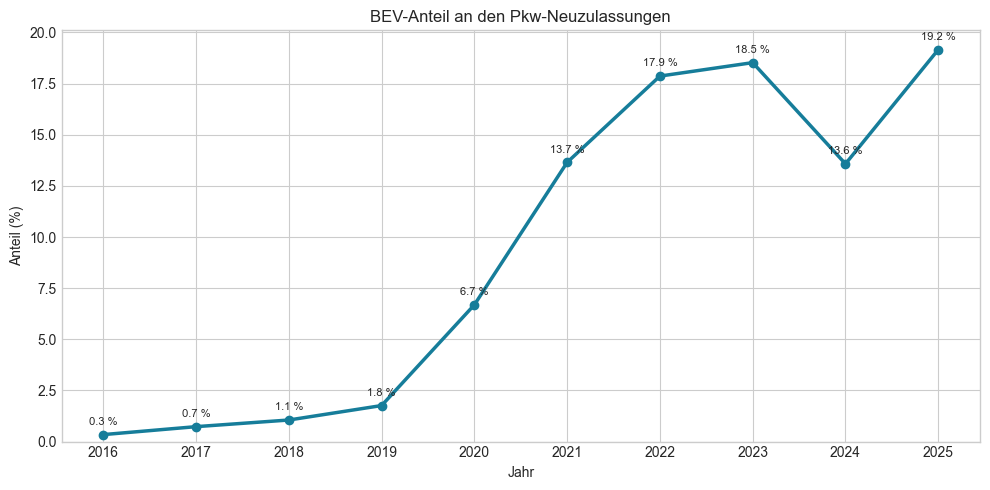

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ev_shares.index, ev_shares['BEV-Anteil (%)'], marker='o', linewidth=2.5, color='#167D9A')
for year, share in ev_shares['BEV-Anteil (%)'].items():
    ax.annotate(f'{share:.1f} %', (year, share), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8)
ax.set(title='BEV-Anteil an den Pkw-Neuzulassungen', xlabel='Jahr', ylabel='Anteil (%)')
ax.set_xticks(ev_shares.index)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Durchschnittliches Wachstum 2020–2025

Für Anteilswerte ist die mittlere jährliche Änderung in **Prozentpunkten** meist die besser interpretierbare Kennzahl. Die CAGR beschreibt dagegen das relative Wachstum des Anteils und wird ergänzend ausgewiesen.

In [4]:
start_share = ev_shares.loc[2020, 'BEV-Anteil (%)']
end_share = ev_shares.loc[2025, 'BEV-Anteil (%)']
years_between = 2025 - 2020
average_pp_growth = (end_share - start_share) / years_between
share_cagr = (end_share / start_share) ** (1 / years_between) - 1

growth_summary = pd.Series({
    'BEV-Anteil 2020 (%)': start_share,
    'BEV-Anteil 2025 (%)': end_share,
    'Mittlere jährliche Änderung (Prozentpunkte/Jahr)': average_pp_growth,
    'CAGR des BEV-Anteils (%/Jahr)': 100 * share_cagr,
})
growth_summary.round(3).to_frame('Wert')

,Wert
BEV-Anteil 2020 (%),6.687
BEV-Anteil 2025 (%),19.159
Mittlere jährliche Änderung (Prozentpunkte/Jahr),2.494
CAGR des BEV-Anteils (%/Jahr),23.433


## Pfade bis 2050

Die neue Baseline schreibt die mittlere historische Änderung von 2020–2025 linear fort. Der stärkere Förderpfad erhöht diese historische Baseline-Steigung um 25 %. Der Parameter `stronger_multiplier` kann direkt angepasst werden; 1,10 bedeutet beispielsweise 10 % mehr jährliche Zunahme. Alle Pfade werden bei 100 % gedeckelt.

In [5]:
path_years = np.arange(2025, 2051, 5)
baseline_values = np.minimum(100, end_share + average_pp_growth * (path_years - 2025))

stronger_multiplier = 1.25
stronger_values = np.minimum(100, end_share + average_pp_growth * stronger_multiplier * (path_years - 2025))

paths = pd.DataFrame({
    'baseline_ev_growth (historischer Trend)': baseline_values,
    f'staerkere_Foerderung_{stronger_multiplier:.2f}x': stronger_values,
}, index=path_years)
paths.index.name = 'Jahr'
paths.round(3)

,baseline_ev_growth (historischer Trend),staerkere_Foerderung_1.25x
Jahr,,
2025,19.159,19.159
2030,31.632,34.750
2035,44.104,50.340
2040,56.577,65.931
2045,69.049,81.521
2050,81.521,97.112


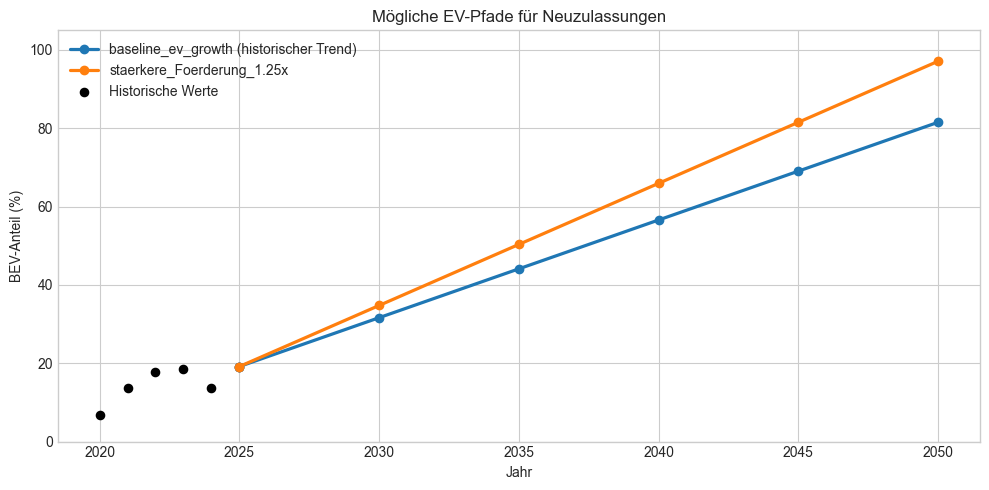

In [6]:
ax = paths.plot(figsize=(10, 5), marker='o', linewidth=2.3)
ax.scatter(ev_shares.loc[2020:2025].index, ev_shares.loc[2020:2025, 'BEV-Anteil (%)'], color='black', s=35, label='Historische Werte')
ax.set(title='Mögliche EV-Pfade für Neuzulassungen', xlabel='Jahr', ylabel='BEV-Anteil (%)', ylim=(0, 105))
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
baseline_path_for_config = {str(year): round(float(value), 6) for year, value in zip(path_years, baseline_values)}
stronger_path_for_config = {str(year): round(float(value), 6) for year, value in zip(path_years, stronger_values)}
print(json.dumps({
    'baseline_ev_growth': baseline_path_for_config,
    'stronger_ev_growth': stronger_path_for_config,
}, indent=2, ensure_ascii=False))

{
  "baseline_ev_growth": {
    "2025": 19.159291,
    "2030": 31.631714,
    "2035": 44.104136,
    "2040": 56.576559,
    "2045": 69.048981,
    "2050": 81.521404
  },
  "stronger_ev_growth": {
    "2025": 19.159291,
    "2030": 34.74982,
    "2035": 50.340348,
    "2040": 65.930876,
    "2045": 81.521404,
    "2050": 97.111932
  }
}


**Hinweis zur Interpretation:** Die CAGR von 2020–2025 ist wegen des sehr niedrigen Ausgangsniveaus und der sprunghaften Marktentwicklung hoch. Eine exponentielle Fortschreibung würde schnell 100 % erreichen. Für Szenariopfade ist daher eine Steigerung in Prozentpunkten mit expliziter Deckelung meist robuster. Der Einbruch 2024 zeigt außerdem, dass fünf historische Jahre keine stabile langfristige Trendperiode garantieren.